# Full workflow: external gate plane + band structure + field sweep
This notebook uses the `semiconductor` helpers to apply an external charged plane potential in GPAW, visualize it, compute a band structure along a k-path, and sweep field strengths while saving results after each step for safe interruption/restart.


In [1]:
# Imports
import os
import sys
import csv
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
from gpaw import restart

# When running a notebook from inside this folder, import local modules directly
sys.path.insert(0, os.path.abspath('.'))

from external_potentials import ChargedPlanePotential, register_with_gpaw
from gpaw_hooks import apply_external
from analysis import compute_gap, sweep_field_gaps, band_structure_with_path
from viz import plot_potential_slice, compute_external_grid

# Ensure our custom external potential can be deserialized by GPAW restarts
register_with_gpaw()


In [2]:
# Paths and output setup
gpw_path = '../gpw/ab.gpw'  # adjust if needed
out_dir = '../gpw'  # reuse gpw directory for outputs
os.makedirs(out_dir, exist_ok=True)

# Result files for safe interruption
sweep_csv = os.path.join(out_dir, 'field_sweep_results.csv')
log_txt = os.path.join(out_dir, 'field_sweep.log')

def log(msg):
    timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    line = f'[{timestamp}] {msg}'
    print(line)
    with open(log_txt, 'a', encoding='utf-8') as f:
        f.write(line + '\n')


In [3]:
# Load atoms and base calculator
atoms, calc0 = restart(gpw_path)

# Determine z-plane (e.g., 3 Å above the top layer)
z_atoms = atoms.positions[:, 2]
z_plane = float(z_atoms.max() + 3.0)
z_plane


6.35

## Visualize external potential


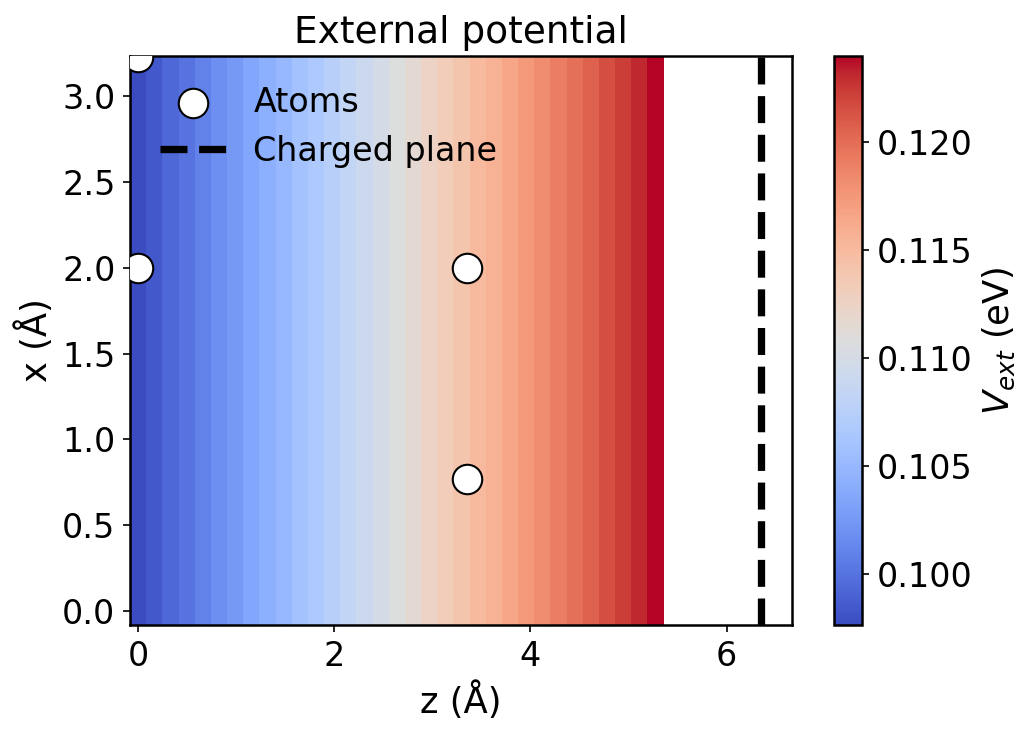

In [5]:
# Choose a small example field strength (A ≈ Ez in eV/Å)
A = 0.005
ext = ChargedPlanePotential(A=A, z_plane=z_plane)

# Visualize the external potential on the GPAW grid
Vext, (x, y, z) = compute_external_grid(calc0, ext, atoms=atoms)
plot_potential_slice(Vext, (x, y, z), atoms)
plt.show()


## Apply potential and run SCF (regular)


In [13]:
calc = apply_external(calc0, atoms, ext, txt=os.path.join(out_dir, f'ab_gate_plane_A{A:.3f}.txt'))
atoms.calc = calc
_ = atoms.get_potential_energy()  # triggers a regular SCF with the external potential
gpw_out = os.path.join(out_dir, f'ab_gate_plane_A{A:.3f}.gpw')
calc.write(gpw_out)
gpw_out


KeyboardInterrupt: 

## Band structure along a k-path


In [14]:
bs = band_structure_with_path(calc, path='GKMG', npoints=30, nbands=16, convergence_bands=8)
energies = bs.energies[0]
EF = calc.get_fermi_level()
E_shift = energies - EF

plt.figure(figsize=(6, 4))
for n in range(E_shift.shape[1]):
    plt.plot(E_shift[:, n])
plt.ylim(-1, 1)
plt.xlabel('k-path index')
plt.ylabel('Energy (eV)')
plt.title('Bilayer with gate potential')
plt.tight_layout()
plt.show()



  ___ ___ ___ _ _ _  
 |   |   |_  | | | | 
 | | | | | . | | | | 
 |__ |  _|___|_____|  25.7.0
 |___|_|             

User:   nico@NicosPC
Date:   Tue Dec 16 20:15:21 2025
Arch:   x86_64
Pid:    7032
CWD:    /mnt/c/Users/Torto/PycharmProjects/DFT_QMB/2_graphene_bilayers/scripts/tight_binding/semiconductor
Python: 3.12.3
gpaw:   /home/nico/gpaw-env/lib/python3.12/site-packages/gpaw
_gpaw:  /home/nico/gpaw-env/lib/python3.12/site-packages/
        _gpaw.cpython-312-x86_64-linux-gnu.so
ase:    /home/nico/gpaw-env/lib/python3.12/site-packages/ase (version 3.26.0)
numpy:  /home/nico/gpaw-env/lib/python3.12/site-packages/numpy (version 2.3.5)
scipy:  /home/nico/gpaw-env/lib/python3.12/site-packages/scipy (version 1.16.3)
libxc:  5.2.3
units:  Angstrom and eV
cores: 1
OpenMP: False
OMP_NUM_THREADS: 1

Input parameters:
  convergence: {bands: 8}
  external: {A: 0.002,
             name: ChargedPlanePotential,
             z_plane: 6.35}
  gpts: [ 14  14 192]
  kpts: {npoints: 30,
         pat

KeyboardInterrupt: 

## Field sweep with interruption-safe saving
- Results are appended to a CSV after each field.
- If the CSV already contains an entry for a field value, it will be skipped (resume capability).


In [36]:
#fields = [0., 0.0025, 0.0050, 0.0075, 0.0100, 0.0125, 0.0150, 0.02, 0.05]#np.linspace(0.0, 0.4, 9)

#fields = np.concatenate(np.linspace(0., 0.02, 100), np.linspace(0.02, 0.5, 50))
#fields = np.concatenate([np.linspace(0., 0.02, 21), np.linspace(0.02, 0.5, 21)])
#fields = np.linspace(0.0, 0.02, 21)#, np.linspace(0.02, 0.5, 21)])
fields = np.linspace(0, 0.02, 21)

In [37]:
fields

array([0.   , 0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008,
       0.009, 0.01 , 0.011, 0.012, 0.013, 0.014, 0.015, 0.016, 0.017,
       0.018, 0.019, 0.02 ])

In [38]:
# Define field values (eV/Å)

# Load existing results (if any) to enable resume
existing = {}
if os.path.exists(sweep_csv):
    with open(sweep_csv, 'r', newline='', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                existing[float(row['Ez'])] = float(row['gap'])
            except Exception:
                pass

# Prepare CSV with header if new
new_file = not os.path.exists(sweep_csv)
if new_file:
    with open(sweep_csv, 'w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow(['Ez', 'gap', 'gpw_path'])

results = []
for Ez in fields:
    Ez = float(Ez)
    if Ez in existing:
        log(f'Skipping Ez={Ez:.3f} eV/Å (already in results)')
        results.append((Ez, existing[Ez]))
        continue

    log(f'Running Ez={Ez:.3f} eV/Å')
    ext = ChargedPlanePotential(A=Ez, z_plane=z_plane)
    calcE = apply_external(calc0, atoms, ext, txt=os.path.join(out_dir, f'gate_A{Ez:.3f}.txt'))

    # Trigger a regular SCF with the external potential
    _ = atoms.get_potential_energy()

    # Save calculator state for this field
    gpw_Ez = os.path.join(out_dir, f'ab_gate_plane_A{Ez:.3f}.gpw')
    calcE.write(gpw_Ez)

    # Band structure and gap
    bsE = band_structure_with_path(calcE, path='GKMG', npoints=30, nbands=16, convergence_bands=8)
    energies = bsE.energies[0]
    EF = calcE.get_fermi_level()
    E = energies - EF
    gap = float(compute_gap(E))
    results.append((Ez, gap))

    # Append to CSV immediately (interruption-safe)
    with open(sweep_csv, 'a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow([f'{Ez:.6f}', f'{gap:.6f}', gpw_Ez])
    log(f'Saved Ez={Ez:.3f}, gap={gap:.4f} eV to CSV and {gpw_Ez}')

# Show summary
for Ez, gap in results:
    print(f'Ez={Ez:.3f} eV/Å -> gap={gap:.4f} eV')


[2025-12-16 20:39:30] Skipping Ez=0.000 eV/Å (already in results)
[2025-12-16 20:39:30] Running Ez=0.001 eV/Å

  ___ ___ ___ _ _ _  
 |   |   |_  | | | | 
 | | | | | . | | | | 
 |__ |  _|___|_____|  25.7.0
 |___|_|             

User:   nico@NicosPC
Date:   Tue Dec 16 20:45:43 2025
Arch:   x86_64
Pid:    7032
CWD:    /mnt/c/Users/Torto/PycharmProjects/DFT_QMB/2_graphene_bilayers/scripts/tight_binding/semiconductor
Python: 3.12.3
gpaw:   /home/nico/gpaw-env/lib/python3.12/site-packages/gpaw
_gpaw:  /home/nico/gpaw-env/lib/python3.12/site-packages/
        _gpaw.cpython-312-x86_64-linux-gnu.so
ase:    /home/nico/gpaw-env/lib/python3.12/site-packages/ase (version 3.26.0)
numpy:  /home/nico/gpaw-env/lib/python3.12/site-packages/numpy (version 2.3.5)
scipy:  /home/nico/gpaw-env/lib/python3.12/site-packages/scipy (version 1.16.3)
libxc:  5.2.3
units:  Angstrom and eV
cores: 1
OpenMP: False
OMP_NUM_THREADS: 1

Input parameters:
  convergence: {bands: 8}
  external: {A: 0.001,
             nam

FileNotFoundError: [Errno 2] No such file or directory: '../gpw/gate_A0.002.txt'

In [9]:
existing

{0.0: 0.329549,
 0.000202: 0.349969,
 0.000404: 0.386631,
 0.000606: 0.404833,
 0.000808: 0.431047,
 0.00101: 0.449032,
 0.001212: 0.209671,
 0.001414: 0.242133,
 0.001616: 0.275646,
 0.001818: 0.304911,
 0.00202: 0.343979,
 0.002222: 0.363726,
 0.002424: 0.399021,
 0.002626: 0.423396,
 0.002828: 0.452878,
 0.00303: 0.481326,
 0.003232: 0.501685,
 0.003434: 0.526036,
 0.003636: 0.549499,
 0.003838: 0.573262,
 0.00404: 0.592034,
 0.004242: 0.608746,
 0.004444: 0.634824,
 0.004646: 0.646745,
 0.004848: 0.665477,
 0.005051: 0.685115,
 0.005253: 0.704507,
 0.005455: 0.716461,
 0.005657: 0.732006,
 0.005859: 0.71799,
 0.006061: 0.70603,
 0.006263: 0.695781,
 0.006465: 0.684965,
 0.006667: 0.672456,
 0.006869: 0.662724,
 0.007071: 0.651601,
 0.007273: 0.641437,
 0.007475: 0.628859,
 0.007677: 0.619813,
 0.007879: 0.608043,
 0.008081: 0.597217,
 0.008283: 0.587875,
 0.008485: 0.576989,
 0.008687: 0.569395,
 0.008889: 0.557264,
 0.009091: 0.547968,
 0.009293: 0.539772,
 0.009495: 0.532082,
 0.

# High-resolution K-zoom bands (BandPath-based zooming) — compute from CSV list and SAVE to disk


In [31]:
from gpaw import GPAW  # noqa: F401 (ensures restart works for all gpw variants)
from ase.dft.kpoints import get_bandpath, kpoint_convert
import numpy as _np
import numpy as np
import csv as _csv

# Zoom settings inspired by save_pi_dft_bands (no pi-band filtering here)
_zoom_path_labels = ['G', 'M', 'K', 'G']
_zoom_npoints_pool = 300          # pool of points before zooming (per full path)
_zoom_label = 'K'                # special point to zoom around
_zoom_distance = 0.5            # diameter (1/Å) in Cartesian k-space for filtering
_nbands = 16
_conv = {'bands': 8}
_overwrite_zoom = True

# Build list of (Ez, gpw_path) strictly from CSV for resume-correctness
fields_from_csv = []
if os.path.exists(sweep_csv):
    with open(sweep_csv, 'r', newline='', encoding='utf-8') as _f:
        _reader = _csv.DictReader(_f)
        for _row in _reader:
            try:
                _Ez = float(_row['Ez'])
            except Exception:
                continue
            _gpw = _row.get('gpw_path') or os.path.join(out_dir, f'ab_gate_plane_A{_Ez:.3f}.gpw')
            fields_from_csv.append((_Ez, _gpw))
else:
    # fallback: use current fields list if CSV missing
    for _Ez in fields:
        _Ez = float(_Ez)
        _gpw = os.path.join(out_dir, f'ab_gate_plane_A{_Ez:.3f}.gpw')
        fields_from_csv.append((_Ez, _gpw))

for Ez, gpw_Ez in np.array(fields_from_csv)[0:1]:
    Ez = float(Ez)
    npz_Ez = os.path.join(out_dir, f'ab_gate_plane_A{Ez:.3f}_bands_KZOOM.npz')

    if not os.path.exists(gpw_Ez):
        log(f"GPW not found for Ez={Ez:.3f}: {gpw_Ez} — skipping K-zoom compute")
        continue

    if os.path.exists(npz_Ez) and not _overwrite_zoom:
        log(f"K-zoom NPZ already exists for Ez={Ez:.3f}: {npz_Ez} — skipping")
        continue

    # Ensure custom potential is registered before restart
    register_with_gpaw()

    # Restart calculator for this field
    atomsK, calcK = restart(gpw_Ez)

    # 1) Build the bandpath and k-point pool
    bp = get_bandpath(_zoom_path_labels, atomsK.cell, npoints=_zoom_npoints_pool)
    kpts = bp.kpts  # reduced coordinates (skpts)
    # Cartesian k-points (1/Å) for distance-based filtering
    kpts_cart = kpoint_convert(atomsK.cell, skpts_kc=kpts)

    # 2) Zoom: filter points within zoom_distance/2 of the special point (Cartesian)
    if _zoom_label not in _zoom_path_labels:
        log(f"Zoom label '{_zoom_label}' not in path {_zoom_path_labels} — skipping Ez={Ez:.3f}")
        continue

    k_special = kpoint_convert(atomsK.cell, skpts_kc=bp.special_points[_zoom_label])
    dist = np.linalg.norm(kpts_cart - k_special, axis=1)
    mask = dist < (_zoom_distance / 2.0)

    if not np.any(mask):
        log(f"No k-points within zoom window for Ez={Ez:.3f} (distance={_zoom_distance}). Consider increasing zoom_distance.")
        continue

    kpts_zoom = kpts[mask]
    kpts_cart_zoom = kpts_cart[mask]

    # 3) Build cumulative x-axis along the filtered path (Cartesian distance)
    if len(kpts_cart_zoom) >= 2:
        diffs = np.diff(kpts_cart_zoom, axis=0)
        seg = np.linalg.norm(diffs, axis=1)
        x = np.concatenate([[0.0], np.cumsum(seg)])
    else:
        x = np.array([0.0])

    # 4) Compute bands with explicit k-points (fixed_density)
    bs_calc = calcK.fixed_density(
        nbands=_nbands,
        symmetry='off',
        kpts=kpts_zoom,  # explicit reduced k-points
        convergence=_conv,
    )
    bs = bs_calc.band_structure()

    E = bs.energies[0]
    EF = float(bs_calc.get_fermi_level())
    E_shift = E - EF

    # 5) Save zoomed dataset
    try:
        os.makedirs(os.path.dirname(npz_Ez), exist_ok=True)
        np.savez_compressed(
            npz_Ez,
            x=np.asarray(x),
            kpts=np.asarray(kpts_zoom),
            kpts_cart=np.asarray(kpts_cart_zoom),
            E=np.asarray(E_shift),
            EF=float(EF),
            Ez=float(Ez),
            nbands=int(_nbands),
            conv_bands=int(_conv['bands']),
            path=np.array(_zoom_path_labels, dtype=object),
            npoints_pool=int(_zoom_npoints_pool),
            zoom_label=str(_zoom_label),
            zoom_distance=float(_zoom_distance),
        )
        log(f"Saved K-zoom bands for Ez={Ez:.3f} to {npz_Ez}")
    except Exception as _e:
        log(f"Error saving K-zoom bands for Ez={Ez:.3f}: {_e}")

# Done saving K-zoom band data for all available fields.



  ___ ___ ___ _ _ _  
 |   |   |_  | | | | 
 | | | | | . | | | | 
 |__ |  _|___|_____|  25.7.0
 |___|_|             

User:   nico@NicosPC
Date:   Tue Dec 16 20:37:37 2025
Arch:   x86_64
Pid:    7032
CWD:    /mnt/c/Users/Torto/PycharmProjects/DFT_QMB/2_graphene_bilayers/scripts/tight_binding/semiconductor
Python: 3.12.3
gpaw:   /home/nico/gpaw-env/lib/python3.12/site-packages/gpaw
_gpaw:  /home/nico/gpaw-env/lib/python3.12/site-packages/
        _gpaw.cpython-312-x86_64-linux-gnu.so
ase:    /home/nico/gpaw-env/lib/python3.12/site-packages/ase (version 3.26.0)
numpy:  /home/nico/gpaw-env/lib/python3.12/site-packages/numpy (version 2.3.5)
scipy:  /home/nico/gpaw-env/lib/python3.12/site-packages/scipy (version 1.16.3)
libxc:  5.2.3
units:  Angstrom and eV
cores: 1
OpenMP: False
OMP_NUM_THREADS: 1

Input parameters:
  convergence: {bands: 8}
  external: {A: 0.0,
             name: ChargedPlanePotential,
             z_plane: 6.35}
  gpts: [ 14  14 192]
  kpts: [[ 0.38095238 -0.23809524  0

# Bands along the full GKMG path (no zoom) — compute from CSV list and SAVE to disk


In [28]:
import numpy as _np2
import os as _os2
from gpaw import restart as _restart2  # ensure restart available in this cell

# Fixed settings exactly as requested
_full_nb = 16
_full_conv = {'bands': 8}
_full_kpts = {'path': 'GKMG', 'npoints': 30}

# Use the same list of fields derived earlier
for _Ez, _gpw_Ez in np.array(fields_from_csv)[0:1]:
    _Ez = float(_Ez)
    if not _os2.path.exists(_gpw_Ez):
        log(f"GPW not found for Ez={_Ez:.3f}: {_gpw_Ez} — skipping full-path compute")
        continue

    _npz_full = _os2.path.join(out_dir, f'ab_gate_plane_A{_Ez:.3f}_bands_FULL.npz')

    # Skip if exists (resume-safe); set overwrite=True to force recompute
    _overwrite_full = True
    if _os2.path.exists(_npz_full) and not _overwrite_full:
        log(f"Full-path NPZ already exists for Ez={_Ez:.3f}: {_npz_full} — skipping")
        continue

    # Ensure custom potential is registered before restart
    register_with_gpaw()

    # Restart the calculator for this field
    _atomsK, _calcK = _restart2(_gpw_Ez)

    # Compute bands with the exact full-path settings (no zoom)
    _bs_calc = _calcK.fixed_density(
        nbands=_full_nb,
        symmetry='off',
        kpts=_full_kpts,
        convergence=_full_conv,
    )
    _bs = _bs_calc.band_structure()

    _energies = _bs.energies[0]
    _EF = float(_bs_calc.get_fermi_level())
    _E = _energies - _EF

    # x-axis from band structure path when available
    _x = getattr(getattr(_bs, 'path', None), 'x', None)
    if _x is None:
        _x = _np2.arange(_E.shape[0])

    try:
        _os2.makedirs(_os2.path.dirname(_npz_full), exist_ok=True)
        _np.savez_compressed(
            _npz_full,
            x=_np.asarray(_x),
            kpts=_np.asarray(getattr(getattr(_bs, 'path', None), 'kpts', [])),
            E=_np.asarray(_E),
            EF=float(_EF),
            Ez=float(_Ez),
            nbands=int(_full_nb),
            conv_bands=int(_full_conv['bands']),
            npoints=int(_full_kpts['npoints']),
            path=str(_full_kpts['path']),
        )
        log(f"Saved full-path bands for Ez={_Ez:.3f} to {_npz_full}")
    except Exception as _e:
        log(f"Error saving full-path bands for Ez={_Ez:.3f}: {_e}")



  ___ ___ ___ _ _ _  
 |   |   |_  | | | | 
 | | | | | . | | | | 
 |__ |  _|___|_____|  25.7.0
 |___|_|             

User:   nico@NicosPC
Date:   Tue Dec 16 20:36:14 2025
Arch:   x86_64
Pid:    7032
CWD:    /mnt/c/Users/Torto/PycharmProjects/DFT_QMB/2_graphene_bilayers/scripts/tight_binding/semiconductor
Python: 3.12.3
gpaw:   /home/nico/gpaw-env/lib/python3.12/site-packages/gpaw
_gpaw:  /home/nico/gpaw-env/lib/python3.12/site-packages/
        _gpaw.cpython-312-x86_64-linux-gnu.so
ase:    /home/nico/gpaw-env/lib/python3.12/site-packages/ase (version 3.26.0)
numpy:  /home/nico/gpaw-env/lib/python3.12/site-packages/numpy (version 2.3.5)
scipy:  /home/nico/gpaw-env/lib/python3.12/site-packages/scipy (version 1.16.3)
libxc:  5.2.3
units:  Angstrom and eV
cores: 1
OpenMP: False
OMP_NUM_THREADS: 1

Input parameters:
  convergence: {bands: 8}
  external: {A: 0.0,
             name: ChargedPlanePotential,
             z_plane: 6.35}
  gpts: [ 14  14 192]
  kpts: {npoints: 30,
         path:

# Load saved full-path band data and PLOT for each field


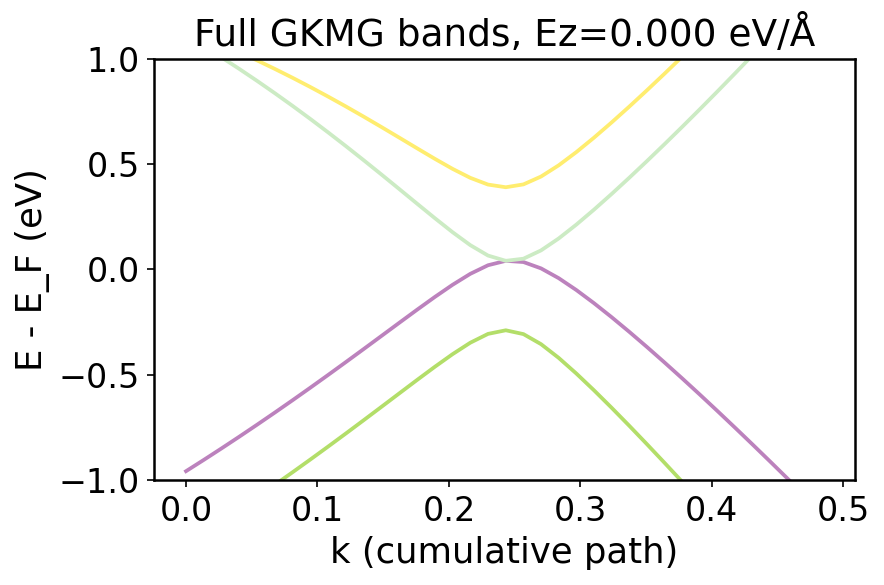

In [32]:
import numpy as _np3
import matplotlib.pyplot as _plt3

for _Ez, _ in fields_from_csv[0:1]:
    _Ez = float(_Ez)
    _npz_Ez = os.path.join(out_dir, f'ab_gate_plane_A{_Ez:.3f}_bands_KZOOM.npz')
    if not os.path.exists(_npz_Ez):
        log(f"Full-path NPZ not found for Ez={_Ez:.3f}: {_npz_Ez} — skipping plot")
        continue

    _data = _np.load(_npz_Ez)
    _x = _data['x']
    _E = _data['E']

    _plt3.figure(figsize=(6, 4))
    for _n in range(_E.shape[1]):
        _plt3.plot(_x, _E[:, _n])
    _plt3.ylim(-1, 1)
    _plt3.xlabel('k (cumulative path)')
    _plt3.ylabel('E - E_F (eV)')
    _plt3.title(f'Full GKMG bands, Ez={_Ez:.3f} eV/Å')
    _plt3.tight_layout()
    _plt3.show()

In [24]:
fields_from_csv[0]

(0.0, '../gpw/ab_gate_plane_A0.000.gpw')